First few rows of the data:
   MEDV     CRIM  INDUS CHAS    NOX     RM    AGE     DIS  RAD  TAX  PTRATIO  \
0   308  9.96654  18.10   no  0.740  6.485  100.0  1.9784   24  666     20.2   
1   462  0.17899   9.69   no  0.585  5.670   28.8  2.7986    6  391     19.2   
2   246  7.99248  18.10   no  0.700  5.520  100.0  1.5331   24  666     20.2   
3   572  0.12932  13.92   no  0.437  6.678   31.1  5.9604    4  289     16.0   
4   398  3.83684  18.10   no  0.770  6.251   91.1  2.2955   24  666     20.2   

        LANDMARK  
0    No Landmark  
1    No Landmark  
2    No Landmark  
3  Shopping Mall  
4    No Landmark  

Correlation matrix:
                            Median Home Value ($1000s)  \
Median Home Value ($1000s)                    1.000000   
% Homes Built Before 1940                    -0.370171   
Avg. Rooms per House                          0.679494   

                            % Homes Built Before 1940  Avg. Rooms per House  
Median Home Value ($1000s)                  -

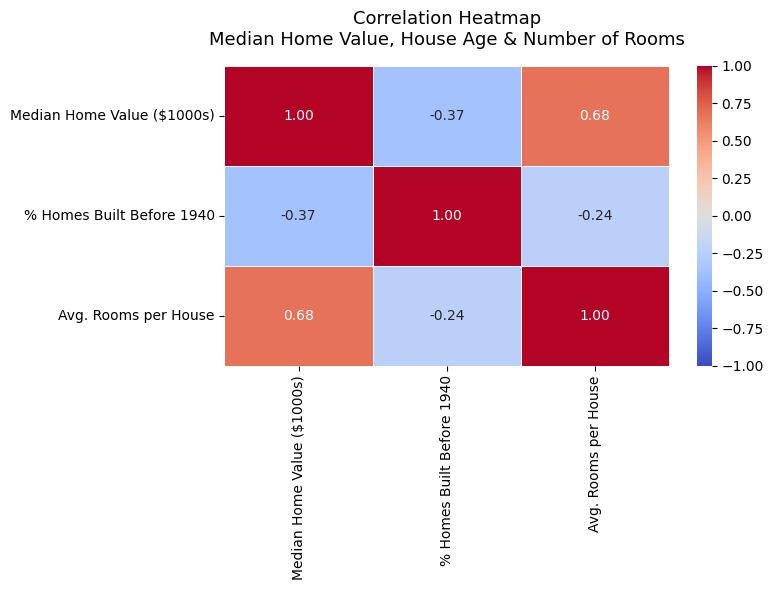


Heatmap saved as assignment1_heatmap.png

── Correlation results 
Median Home Value & % Homes Built Before 1940 : r = -0.37,  p-value = 0.0000
Median Home Value & Avg. Rooms per House       : r = 0.68,  p-value = 0.0000
% Homes Built Before 1940 & Avg. Rooms         : r = -0.24,  p-value = 0.0000


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
 
df = pd.read_csv("1632349boston.csv")
 
print("First few rows of the data:")
print(df.head())
 
# Select the 3 variables the friend asked about 
# MEDV = median home value (in $1,000s)
# AGE = proportion of homes built before 1940 (% of older homes in area)
# RM = average number of rooms per house
 
selected = df[["MEDV", "AGE", "RM"]].copy()
 
# Rename to readable labels for the heatmap
selected.columns = [
    "Median Home Value ($1000s)",
    "% Homes Built Before 1940",
    "Avg. Rooms per House"
]
 
correlation_matrix = selected.corr()
 
print("\nCorrelation matrix:")
print(correlation_matrix)
 
#Draw the heatmap 
plt.figure(figsize=(8, 6))
 
sns.heatmap(
    correlation_matrix,
    annot=True,       # show correlation numbers inside each cell
    fmt=".2f",        # round to 2 decimal places
    cmap="coolwarm",  # red = strong positive, blue = strong negative
    vmin=-1, vmax=1,  # fix scale from -1 to +1
    linewidths=0.5
)
 
plt.title("Correlation Heatmap\nMedian Home Value, House Age & Number of Rooms",
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("assignment1_heatmap.png", dpi=150)
plt.show()
print("\nHeatmap saved as assignment1_heatmap.png")
 
#Individual correlations + p-values 
corr_medv_age, p_medv_age = stats.pearsonr(df["MEDV"], df["AGE"])
corr_medv_rm,  p_medv_rm  = stats.pearsonr(df["MEDV"], df["RM"])
corr_age_rm,   p_age_rm   = stats.pearsonr(df["AGE"],  df["RM"])
 
print("\n── Correlation results ")
print(f"Median Home Value & % Homes Built Before 1940 : r = {corr_medv_age:.2f},  p-value = {p_medv_age:.4f}")
print(f"Median Home Value & Avg. Rooms per House       : r = {corr_medv_rm:.2f},  p-value = {p_medv_rm:.4f}")
print(f"% Homes Built Before 1940 & Avg. Rooms         : r = {corr_age_rm:.2f},  p-value = {p_age_rm:.4f}")
 

In [ ]:
#EXPLANATION OF HEATMAP RESULTS 

# HOW TO READ THE HEATMAP (for a non-technical audience):
# - The heatmap shows a number between -1 and 1 for each pair of variables.
# - A number close to +1 means both variables go up together (positive relationship).
# - A number close to -1 means when one goes up, the other goes down (negative relationship).
# - A number close to 0 means there is no real relationship between the two variables.

# WHAT THE CORRELATIONS MEAN FOR EACH PAIR:
# - MEDV & RM (house price & number of rooms):
#   Positive correlation — neighbourhoods with bigger houses (more rooms)
#   tend to have higher median home values. More space = more value.

# - MEDV & AGE (house price & % homes built before 1940):
#   Negative correlation — neighbourhoods with more pre-1940 homes
#   tend to have lower median home values. Older areas = lower prices.

# - AGE & RM (% old homes & number of rooms):
#   Negative correlation — older neighbourhoods tend to have smaller houses
#   with fewer rooms. Newer homes are generally built bigger.

# HOW TO EXPLAIN THIS TO A FRIEND (non-technical summary):
# - Each square in the heatmap tells us how strongly two things are related.
# - The darker the red, the stronger the positive link —
#    for example, more rooms clearly means a higher house price.
# - The darker the blue, the stronger the negative link —
#    for example, older neighbourhoods tend to have cheaper, smaller homes.

In [18]:
import pandas as pd
import statsmodels.formula.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


df = pd.read_csv("1632349boston.csv")

print("=" * 70)
print("ASSIGNMENT 1: MULTIPLE REGRESSION - MEDIAN HOUSE PRICE (MEDV)")
print("=" * 70)

# Step 1: Create dummy variables 
# Instead we manually drop the correct reference categories:
#   CHAS        -> reference = 'no'           -> drop CHAS_no
#   LANDMARK    -> reference = 'No Landmark'  -> drop LANDMARK_No Landmark

df_model = pd.get_dummies(df, columns=['CHAS', 'LANDMARK'], dtype=int)

# Make column names formula-friendly (replace spaces with underscores)
df_model.columns = df_model.columns.str.replace(' ', '_')

print("\nAll dummy columns created:")
print([c for c in df_model.columns if 'CHAS' in c or 'LANDMARK' in c])

# Manually drop the reference category columns
df_model = df_model.drop(columns=['CHAS_no', 'LANDMARK_No_Landmark'])

print("\nColumns after dropping reference categories:")
print(df_model.columns.tolist())

# Step 2: Run the full regression model 
# sm.ols('Dependent ~ Independent1 + Independent2 + ...', data=df).fit()

formula_full = ('MEDV ~ CRIM + INDUS + NOX + RM + AGE + DIS + RAD + TAX + PTRATIO '
                '+ CHAS_yes '
                '+ LANDMARK_Museum + LANDMARK_Park + LANDMARK_Shopping_Mall + LANDMARK_Stadium')

model_full = sm.ols(formula_full, data=df_model).fit()

print("\n" + "=" * 70)
print("FULL MODEL SUMMARY (before multicollinearity check)")
print("=" * 70)
print(model_full.summary())

#Step 3: Check multicollinearity using VIF 

print("\n" + "=" * 70)
print("MULTICOLLINEARITY CHECK: Variance Inflation Factors (VIF)")
print("=" * 70)
print("Rule from class: VIF > 5 = multicollinearity problem -> remove the variable\n")

X_vars = ['CRIM', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO',
          'CHAS_yes',
          'LANDMARK_Museum', 'LANDMARK_Park', 'LANDMARK_Shopping_Mall', 'LANDMARK_Stadium']

# Build numeric float matrix with intercept for VIF calculation
X = df_model[X_vars].copy().astype(float)
X.insert(0, 'Intercept', 1.0)

vif_data = pd.DataFrame()
vif_data['Variable'] = X_vars
vif_data['VIF'] = [variance_inflation_factor(X.values, i + 1)
                   for i in range(len(X_vars))]
vif_data['Problem?'] = vif_data['VIF'].apply(
    lambda v: 'REMOVE (VIF > 5)' if v > 5 else 'OK')

print(vif_data.to_string(index=False))

# Identify variables to remove
high_vif = vif_data[vif_data['VIF'] > 5]['Variable'].tolist()
print(f"\nVariables with VIF > 5 (removed from final model): {high_vif if high_vif else 'None'}")

#Step 4: Run final model after removing high-VIF variables 
final_vars = [v for v in X_vars if v not in high_vif]
formula_final = 'MEDV ~ ' + ' + '.join(final_vars)

print("\n" + "=" * 70)
print("FINAL MODEL (after removing multicollinear variables)")
print(f"Formula used: {formula_final}")
print("=" * 70)

model_final = sm.ols(formula_final, data=df_model).fit()
print(model_final.summary())

#Step 5: APA formatted table 
print("\n" + "=" * 100)
print("APA TABLE: Multiple Regression Results Predicting Median Home Value (MEDV, in $1,000s)")
print("=" * 100)

params = model_final.params
std_err = model_final.bse
t_vals = model_final.tvalues
p_vals = model_final.pvalues
conf_int = model_final.conf_int()

labels = {
    'Intercept':              'Intercept',
    'CRIM':                   'Crime Rate',
    'INDUS':                  'Non-Retail Business (%)',
    'NOX':                    'Nitric Oxides Concentration',
    'RM':                     'Avg. Rooms per House',
    'AGE':                    '% Homes Built Before 1940',
    'DIS':                    'Distance to Employment Centre',
    'RAD':                    'Highway Accessibility',
    'TAX':                    'Property Tax Rate',
    'PTRATIO':                'Pupil-Teacher Ratio',
    'CHAS_yes':               'Borders Charles River (yes)',
    'LANDMARK_Museum':        'Landmark: Museum',
    'LANDMARK_Park':          'Landmark: Park',
    'LANDMARK_Shopping_Mall': 'Landmark: Shopping Mall',
    'LANDMARK_Stadium':       'Landmark: Stadium',
}

print(f"\n{'Variable':<32} {'B':>9} {'SE':>9} {'t':>9} {'p':>9} {'95% CI Lower':>14} {'95% CI Upper':>14}")
print("-" * 100)

for var in params.index:
    label = labels.get(var, var)
    b = params[var]
    se = std_err[var]
    t = t_vals[var]
    p = p_vals[var]
    ci_lo = conf_int.loc[var, 0]
    ci_hi = conf_int.loc[var, 1]

    if p < 0.001:
        sig = '***'
    elif p < 0.01:
        sig = '**'
    elif p < 0.05:
        sig = '*'
    else:
        sig = ''

    p_str = '< .001' if p < 0.001 else f'{p:.3f}'
    print(f"{label:<32} {b:>9.3f} {se:>9.3f} {t:>9.3f} {p_str:>9} {ci_lo:>14.3f} {ci_hi:>14.3f}  {sig}")

print("-" * 100)
print(f"\nNote. N = {int(model_final.nobs)}. "
      f"R2 = {model_final.rsquared:.3f}, "
      f"Adjusted R2 = {model_final.rsquared_adj:.3f}, "
      f"F({int(model_final.df_model)}, {int(model_final.df_resid)}) = {model_final.fvalue:.3f}, "
      f"p {'< .001' if model_final.f_pvalue < 0.001 else f'= {model_final.f_pvalue:.3f}'}.")
print("* p < .05. ** p < .01. *** p < .001.")
print("\nReference categories: CHAS = 'no'; LANDMARK = 'No Landmark'.")
print(f"Variables removed due to multicollinearity (VIF > 5): {high_vif if high_vif else 'None'}")

ASSIGNMENT 1: MULTIPLE REGRESSION - MEDIAN HOUSE PRICE (MEDV)

All dummy columns created:
['CHAS_no', 'CHAS_yes', 'LANDMARK_Museum', 'LANDMARK_No_Landmark', 'LANDMARK_Park', 'LANDMARK_Shopping_Mall', 'LANDMARK_Stadium']

Columns after dropping reference categories:
['MEDV', 'CRIM', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'CHAS_yes', 'LANDMARK_Museum', 'LANDMARK_Park', 'LANDMARK_Shopping_Mall', 'LANDMARK_Stadium']

FULL MODEL SUMMARY (before multicollinearity check)
                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.879
Method:                 Least Squares   F-statistic:                     237.5
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          6.21e-195
Time:                        09:23:06   Log-Likelihood:                -2523.8
No. Observations:                 4